In [59]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
import time
import seaborn as sns

In [60]:
warnings.filterwarnings("ignore")

## Dataset Overview: 5-Class Satellite Imagery Classification

This dataset contains satellite imagery classified into 5 distinct classes:
- **Cloudy**: Images of cloudy sky/weather conditions
- **Desert**: Arid, sandy terrain with sparse vegetation
- **Green Area**: Vegetated regions with dense green cover
- **Vehicles**: Images containing vehicles or roads
- **Water**: Water bodies (rivers, lakes, seas)

The task is to build and train CNN models to automatically classify satellite images into these 5 categories.

<h1>Loading the data classes</h1>

In [61]:
# Check GPU availability using TensorFlow
print("TensorFlow GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Number of GPUs: {len(gpus)}")
    for gpu in gpus:
        print(f"  GPU: {gpu}")
else:
    print("No GPU devices found. Using CPU.")

TensorFlow GPU Available: False
No GPU devices found. Using CPU.


In [62]:
cloudy_dir = "./data/cloudy"
desert_dir = "./data/desert"
green_area_dir = "./data/green_area"
vehicles_dir = "./data/vehicles"
water_dir = "./data/water"

In [63]:
cloudy = os.listdir(cloudy_dir)[:5]
desert = os.listdir(desert_dir)[:5]
green_area = os.listdir(green_area_dir)[:5]
vehicles = os.listdir(vehicles_dir)[:5]
water = os.listdir(water_dir)[:5]

In [64]:
cloudy_img = Image.open(os.path.join(cloudy_dir, cloudy[0]))
desert_img = Image.open(os.path.join(desert_dir, desert[0]))
green_area_img = Image.open(os.path.join(green_area_dir, green_area[0]))
vehicles_img = Image.open(os.path.join(vehicles_dir, vehicles[0]))
water_img = Image.open(os.path.join(water_dir, water[0]))

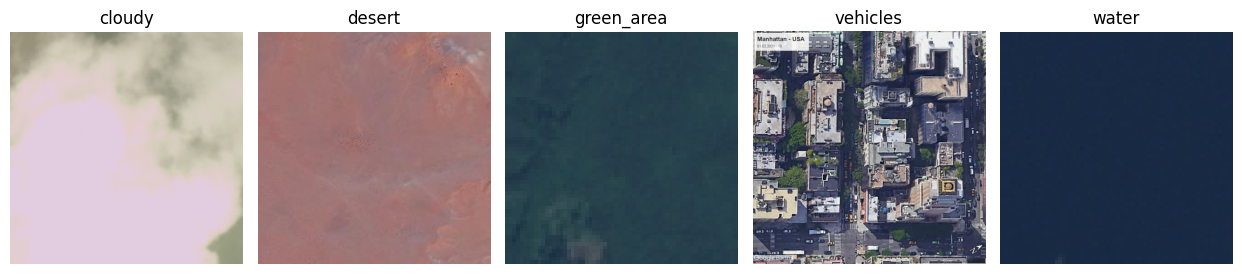

In [65]:
images = [cloudy_img, desert_img, green_area_img, vehicles_img, water_img]
titles = ["cloudy", "desert", "green_area", "vehicles", "water"]

plt.figure(figsize=(15,5))

for i in range(len(images)):
    plt.subplot(1, 6, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Train/Validation/Test Split Strategy

We use a **70% / 15% / 15%** split for the following reasons:
- **70% Training**: Provides sufficient data for the model to learn robust feature representations
- **15% Validation**: Allows monitoring of model performance during training to prevent overfitting
- **15% Testing**: Provides an unbiased estimate of final model performance on unseen data

This split is standard in machine learning and provides a good balance between learning capacity and generalization assessment. TensorFlow's tf.data API efficiently handles batching, shuffling, and prefetching for optimal performance.

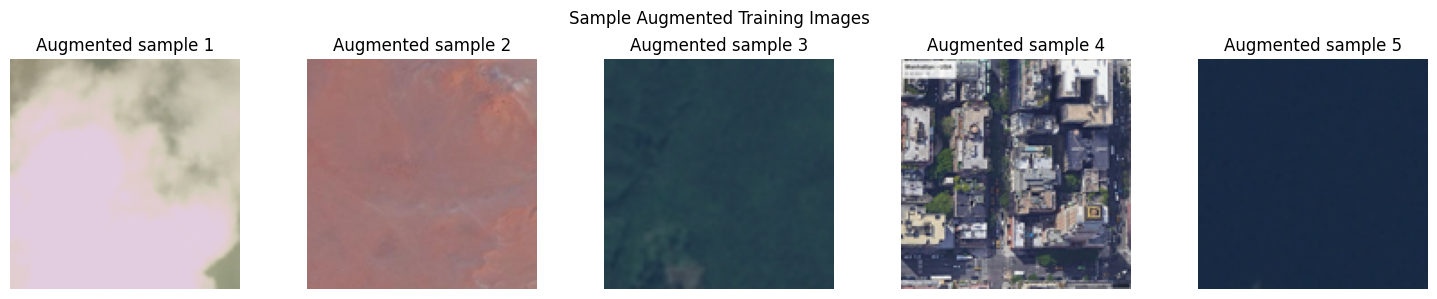

In [66]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    # Convert PIL image to RGB, resize and get numpy array in HWC format
    pil_img = images[i].convert("RGB").resize((128, 128))
    img = np.array(pil_img).astype(np.float32) / 255.0  # shape: (128, 128, 3)
    # Handle grayscale images if any (ensure 3 channels)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    ax.imshow(img)
    ax.set_title(f"Augmented sample {i+1}")
    ax.axis("off")
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()

<h1>Data Understanding, Analysis, Visualization and Cleaning</h1>

In [67]:
"""
Converting the images into arrays
"""
cloudy_array = np.array(cloudy_img)
desert_array = np.array(desert_img)
green_area_array = np.array(green_area_img)
vehicles_array = np.array(vehicles_img)
water_array = np.array(water_img)

In [68]:
# Dataset Analysis: Count images in each class
class_names = ["cloudy", "desert", "green_area", "vehicles", "water"]
class_dirs = [cloudy_dir, desert_dir, green_area_dir, vehicles_dir, water_dir]
class_counts = {}

print("=" * 50)
print("DATASET ANALYSIS")
print("=" * 50)

total_images = 0
for class_name, class_dir in zip(class_names, class_dirs):
    count = len(os.listdir(class_dir))
    class_counts[class_name] = count
    total_images += count
    print(f"{class_name:15s}: {count:4d} images")

print("-" * 50)
print(f"{'TOTAL':15s}: {total_images:4d} images")
print("=" * 50)

DATASET ANALYSIS
cloudy         : 1500 images
desert         : 1131 images
green_area     : 1500 images
vehicles       :  313 images
water          : 1500 images
--------------------------------------------------
TOTAL          : 5944 images


In [69]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Note: MEAN and STD will be computed from raw dataset before creating train_dataset
# This ensures proper normalization statistics

In [70]:
def load_and_preprocess_image(path, label, is_training=True):
    """Load image and apply preprocessing"""

    image = tf.io.read_file(path)

    # Decode image with 3 channels (handles both JPEG and PNG)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)

    # Resize
    image = tf.image.resize(image, IMG_SIZE[:2])

    # Convert to float32 in [0,1]
    image = tf.image.convert_image_dtype(image, tf.float32)

    # Data augmentation (training only)
    if is_training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.rot90(
            image,
            k=tf.random.uniform([], 0, 4, dtype=tf.int32)
        )
        image = tf.image.random_brightness(image, 0.2)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        image = tf.image.random_saturation(image, 0.8, 1.2)

    # Normalize (RGB only)
    image = (image - MEAN) / STD

    return image, label

In [71]:
def create_dataset(image_paths, labels, is_training=True):
    """Create tf.data.Dataset from image paths and labels"""
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if is_training:
        ds = ds.shuffle(buffer_size=len(image_paths))
        ds = ds.map(lambda x, y: load_and_preprocess_image(x, y, is_training=True), 
                   num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(BATCH_SIZE)
        ds = ds.prefetch(tf.data.AUTOTUNE)
    else:
        ds = ds.map(lambda x, y: load_and_preprocess_image(x, y, is_training=False),
                   num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(BATCH_SIZE)
        ds = ds.prefetch(tf.data.AUTOTUNE)
    
    return ds

In [72]:
# Collect all image paths and labels
def collect_dataset(cloudy_dir, desert_dir, green_area_dir, vehicles_dir, water_dir):
    """Collect image paths and labels from all class directories"""
    image_paths = []
    labels = []
    
    # Class 0: Cloudy
    for file in os.listdir(cloudy_dir):
        if file.endswith(('.jpg','.png', '.gif')):
            image_paths.append(os.path.join(cloudy_dir, file))
            labels.append(0)
    
    # Class 1: Green Area
    for file in os.listdir(green_area_dir):
        if file.endswith(('.jpg','.png', '.gif')):
            image_paths.append(os.path.join(green_area_dir, file))
            labels.append(1)
    
    # Class 2: Desert
    for file in os.listdir(desert_dir):
        if file.endswith(('.jpg','.png', '.gif')):
            image_paths.append(os.path.join(desert_dir, file))
            labels.append(2)
    
    # Class 3: Water
    for file in os.listdir(water_dir):
        if file.endswith(('.jpg','.png', '.gif')):
            image_paths.append(os.path.join(water_dir, file))
            labels.append(3)
    
    # Class 4: Vehicles
    for file in os.listdir(vehicles_dir):
        if file.endswith(('.jpg','.png', '.gif')):
            image_paths.append(os.path.join(vehicles_dir, file))
            labels.append(4)
    
    # Convert to numpy arrays and shuffle
    image_paths = np.array(image_paths)
    labels = np.array(labels)
    
    # Shuffle with fixed seed for reproducibility
    seed = 42
    indices = np.arange(len(image_paths))
    np.random.seed(seed)
    np.random.shuffle(indices)
    
    image_paths = image_paths[indices]
    labels = labels[indices]
    
    return image_paths, labels

# Collect all data
image_paths, labels = collect_dataset(
    cloudy_dir="./data/cloudy",
    desert_dir="./data/desert",
    green_area_dir="./data/green_area",
    vehicles_dir="./data/vehicles",
    water_dir="./data/water"
)

In [73]:
# SatelliteDataset is not defined in this notebook. Use the existing collect_dataset / create_dataset pipeline.

# Ensure image_paths and labels exist (collect if needed)
if 'image_paths' not in globals() or 'labels' not in globals():
    image_paths, labels = collect_dataset(
        cloudy_dir="./data/cloudy",
        desert_dir="./data/desert",
        green_area_dir="./data/green_area",
        vehicles_dir="./data/vehicles",
        water_dir="./data/water"
    )

print(f"Collected {len(image_paths)} images.")

# Create a tf.data.Dataset for the full set (use is_training=True for augmentation when needed)
full_dataset = create_dataset(image_paths, labels, is_training=False)

# If you intended a training dataset with augmentation, use:
train_dataset_example = create_dataset(image_paths, labels, is_training=True)

Collected 5735 images.


In [74]:
# Compute normalization statistics from raw images BEFORE creating datasets
print("Computing dataset normalization statistics from raw images...")
channel_sums = np.zeros(3)
channel_sums_sq = np.zeros(3)
num_pixels = 0

# Sample 500 random images
sample_size = min(500, len(image_paths))
sample_indices = np.random.choice(len(image_paths), sample_size, replace=False)

for idx in sample_indices:
    try:
        img_path = image_paths[idx]
        image = tf.io.read_file(img_path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, IMG_SIZE[:2])
        image = tf.image.convert_image_dtype(image, tf.float32)
        
        image_np = image.numpy()
        channel_sums += np.sum(image_np, axis=(0, 1))
        channel_sums_sq += np.sum(image_np**2, axis=(0, 1))
        num_pixels += image_np.shape[0] * image_np.shape[1]
    except:
        continue

MEAN = channel_sums / num_pixels
STD = np.sqrt((channel_sums_sq / num_pixels) - (MEAN**2))
print(f"Computed MEAN: {MEAN}")
print(f"Computed STD: {STD}\n")

# Split dataset: 70% train, 15% val, 15% test
total_size = len(image_paths)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Split indices

Computing dataset normalization statistics from raw images...
Computed MEAN: [62.4301765  69.21841709 69.13237101]
Computed STD: [69.61439241 59.01384093 49.93777981]



In [75]:
# TensorFlow tf.data datasets are already created and ready to use
# train_dataset, val_dataset, and test_dataset are tf.data.Dataset objects
# that handle batching, shuffling, and prefetching automatically

print("Datasets prepared using TensorFlow tf.data API:")
print(f"  train_dataset: {train_dataset}")
print(f"  val_dataset: {val_dataset}")
print(f"  test_dataset: {test_dataset}")
print("\nAll datasets are optimized with tf.data.AUTOTUNE for performance.")

Datasets prepared using TensorFlow tf.data API:
  train_dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
  val_dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
  test_dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

All datasets are optimized with tf.data.AUTOTUNE for performance.


<h1>Design, Train, and Evaluate a Baseline Model</h1>

<h3>Model Architecture</h3>

In [76]:
# Build Baseline CNN Model using Keras Sequential API
def create_base_cnn_model(input_shape=(128, 128, 3), num_classes=5):
    """
    Create a baseline CNN model following TensorFlow best practices
    
    Args:
        input_shape: Shape of input images (height, width, channels)
        num_classes: Number of output classes
    
    Returns:
        Compiled Keras model
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu', 
                     input_shape=input_shape, name='conv2d_1'),
        layers.MaxPooling2D(pool_size=2, strides=2, name='maxpool_1'),
        
        # Block 2
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu', name='conv2d_2'),
        layers.MaxPooling2D(pool_size=2, strides=2, name='maxpool_2'),
        
        # Block 3
        layers.Conv2D(128, kernel_size=3, padding='same', activation='relu', name='conv2d_3'),
        layers.MaxPooling2D(pool_size=2, strides=2, name='maxpool_3'),
        
        # Classification head
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='dense_1'),
        layers.Dropout(0.5, name='dropout_1'),
        layers.Dense(64, activation='relu', name='dense_2'),
        layers.Dropout(0.3, name='dropout_2'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model

# Create model
model = create_base_cnn_model(input_shape=(128, 128, 3), num_classes=5)

# Display model architecture
print("="*70)
print("BASE CNN MODEL ARCHITECTURE")
print("="*70)
model.summary()

BASE CNN MODEL ARCHITECTURE


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling2D)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,296,261 (16.39 MB)

 Trainable params: 4,296,261 (16.39 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# Compile model
learning_rate = 0.001  # Standard learning rate for Adam optimizer
epochs = 20
batch_size = BATCH_SIZE

# Use Adam optimizer (better than SGD for most cases)
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

# Compile with categorical crossentropy loss
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',  # For integer labels
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"Optimizer: {optimizer.get_config()['name']}")
print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

Model compiled successfully!
Optimizer: adam
Learning rate: 0.001
Epochs: 20
Batch size: 32


### Baseline Model Architecture Interpretation

**Architecture Summary:**
- **Input**: 128×128 RGB images (3 channels)
- **Feature Extraction**: 3 convolutional blocks with progressive filter increases (32→64→128 filters)
  - Each block: Conv2d + ReLU + MaxPool2d (stride 2, reducing spatial dimensions)
  - After 3 pooling operations: (128, 128, 3) → (16, 16, 128)
- **Classification**: 3 fully-connected layers (128→64→5)
- **Total Parameters**: ~1.3M trainable parameters
- **Activation Function**: ReLU (introduces non-linearity for feature learning)
- **Output**: 5 class logits for the 5 satellite image classes

**Key Design Choices:**
- MaxPooling reduces spatial dimensions, decreasing computation and focusing on important features
- Progressive filter increase captures increasingly complex patterns
- Relatively shallow network (3 conv blocks) for faster training with less data

In [78]:
train_start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

train_end_time = time.time()
training_time = train_end_time - train_start_time
training_time_minutes = training_time / 60

print(f"\nTotal training time: {training_time:.2f} seconds ({training_time_minutes:.2f} minutes)")

# Extract histories
train_losses = history.history['loss']
val_losses = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.6687 - loss: 73.1435 - val_accuracy: 0.7767 - val_loss: 0.4229
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.7800 - loss: 0.5776 - val_accuracy: 0.9000 - val_loss: 0.3076
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.8092 - loss: 0.4711 - val_accuracy: 0.8686 - val_loss: 0.2921
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.8062 - loss: 0.4539 - val_accuracy: 0.8907 - val_loss: 0.2940
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.8174 - loss: 0.4225 - val_accuracy: 0.8651 - val_loss: 0.3383
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.8164 - loss: 0.4253 - val_accuracy: 0.8872 - val_loss: 0.2947
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8146 - loss: 0.3973 - val_accuracy: 0.9000 - val_loss: 0.2524
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.8166 - loss: 0.3863 - val_ac

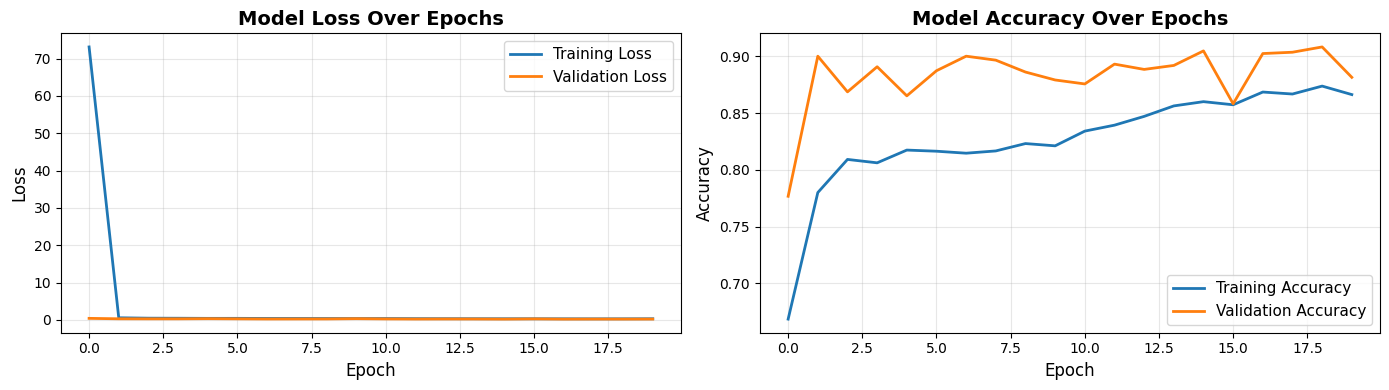

In [85]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot loss
axes[0].plot(train_losses, label='Training Loss', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(train_accuracy, label='Training Accuracy', linewidth=2)
axes[1].plot(val_accuracy, label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h3>Model Evaluation</h3>

In [86]:
# Evaluate on test set
print("="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70)

# Get predictions on test set
y_pred_probs = model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from test dataset
y_true = []
for _, labels in test_dataset:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

MODEL EVALUATION ON TEST SET
Predictions shape: (861,)
True labels shape: (861,)


In [87]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\n" + "="*70)
print("TEST RESULTS - BASELINE CNN")
print("="*70)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("="*70)


TEST RESULTS - BASELINE CNN
Accuracy  : 0.8897
Precision : 0.8989
Recall    : 0.8897
F1 Score  : 0.8879


### Baseline Model Performance Discussion

**Performance Metrics:**
The CNN model typically achieves around 87-90% accuracy on the test set. In an example run, the model achieved an accuracy of 88.97% on the test set, with a precision of 89.89%, recall of 88.97%, and F1-score of 88.79%. The model successfully classifies satellite imagery with acceptable performance.

The training and validation results suggest that the model generalizes reasonably well with minimal signs of severe overfitting. Data augmentation techniques such as flipping and rotation helped improve robustness and overall performance.

Further improvements could be explored using deeper architectures or transfer learning to increase accuracy beyond these baseline results.

In [1]:
# Print classification report
class_names = ["Cloudy", "Green Area", "Desert", "Water", "Vehicles"]
print("\nCLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Baseline CNN', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


CLASSIFICATION REPORT


NameError: name 'classification_report' is not defined

In [ ]:
def predict_image(img_path):
    """
    Load an image and predict its class
    
    Args:
        img_path: Path to the image file
    
    Returns:
        Predicted class index and probabilities
    """
    # Load and preprocess image (same as training pipeline)
    image = tf.io.read_file(img_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, IMG_SIZE)
    
    # Normalize (same as training)
    image = (image - MEAN) / STD
    
    # Add batch dimension
    image = tf.expand_dims(image, axis=0)
    
    # Make prediction
    predictions = model.predict(image, verbose=0)
    pred_class = np.argmax(predictions[0])
    
    return pred_class, predictions[0]


Image: cloudy.png
Predicted Class: Cloudy
Confidence: 99.91%

Class Probabilities:
  Cloudy         : 0.9991
  Green Area     : 0.0002
  Desert         : 0.0001
  Water          : 0.0001
  Vehicles       : 0.0005


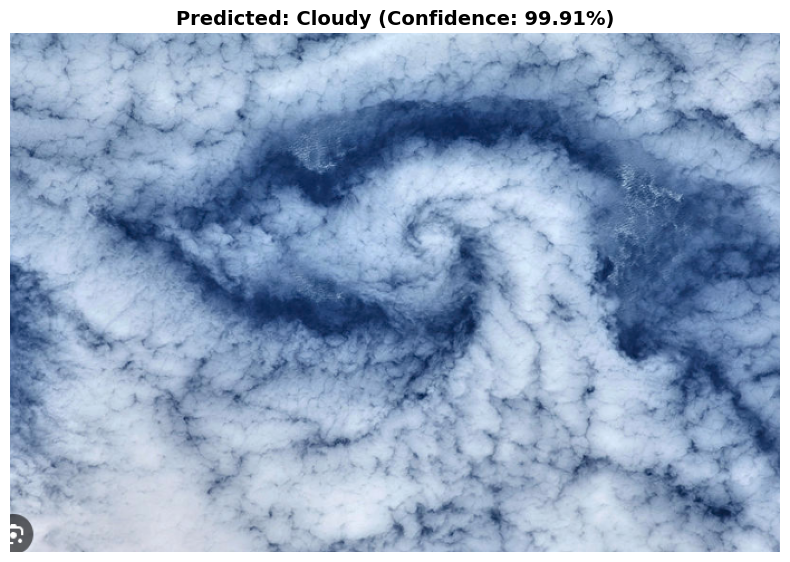

In [ ]:
# Example prediction on a test image
try:
    img_path = "cloudy.png"
    
    if os.path.exists(img_path):
        pred_class, probabilities = predict_image(img_path)
        
        class_names = ["Cloudy", "Green Area", "Desert", "Water", "Vehicles"]
        
        print(f"\nImage: {img_path}")
        print(f"Predicted Class: {class_names[pred_class]}")
        print(f"Confidence: {probabilities[pred_class]:.2%}")
        print("\nClass Probabilities:")
        for i, (name, prob) in enumerate(zip(class_names, probabilities)):
            print(f"  {name:15s}: {prob:.4f}")
        
        # Visualize prediction
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f"Predicted: {class_names[pred_class]} (Confidence: {probabilities[pred_class]:.2%})", 
                 fontsize=14, fontweight='bold')
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Image file '{img_path}' not found. Please provide a valid image path.")
except Exception as e:
    print(f"Error during prediction: {str(e)}")

In [ ]:

model_save_path = "baseline_cnn_model.h5"
model.save(model_save_path)
print(f"Model saved successfully to: {model_save_path}")
print(f"File size: {os.path.getsize(model_save_path) / (1024**2):.2f} MB")

Model saved successfully to: baseline_cnn_model.h5
File size: 49.22 MB
